[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dines\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dines\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Shape: (2210, 7)
    AirLine_Name  Rating - 10                          Title  \
0  AirAsia India          6.0          "crew were welcoming"   
1  AirAsia India          1.0     "furious and disappointed"   
2  AirAsia India         10.0  "amazing service and support"   
3  AirAsia India          1.0      "Waste of time and money"   
4  AirAsia India          8.0   "thumbs up to boarding crew"   

                     Name               Date  \
0                V Bakshi  14th October 2023   
1                 G Oscar  14th October 2023   
2             Rahul Verma  14th October 2023   
3                 G Akron  14th October 2023   
4  Sirajudeen Jawahar ali  14th October 2023   

                                              Review Recommend  
0  âœ… Trip Verified | I had booked this fare at ...       yes  
1  âœ… Trip Verified | I travel at least four tim...        no  
2  âœ… Trip Verified | Taking this opportunity to...       yes  
3  âœ… Trip Verified | The worst airlines in the 

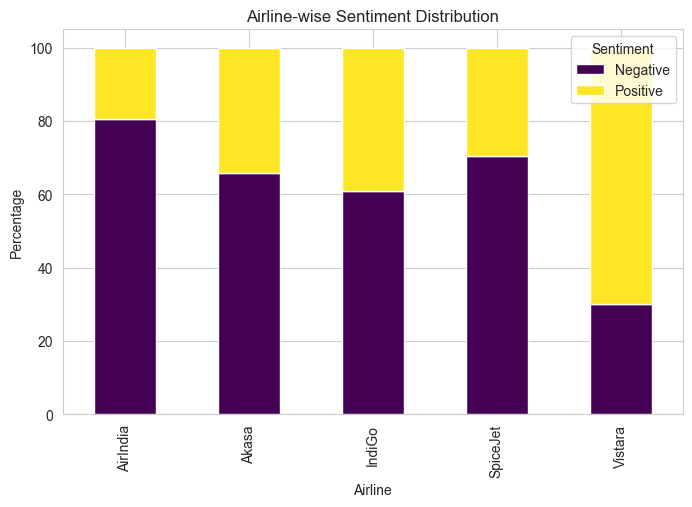


✈ Airline: Akasa

🌟 Positive Experience Drivers:
           Phrase    Score
       cabin crew 0.126180
     ground staff 0.095688
         leg room 0.059593
experience flying 0.058067
      crew member 0.056028
       seat pitch 0.055577
   process smooth 0.044568
        free cost 0.031792
      last moment 0.029077
 seat comfortable 0.019804

⚠ Key Customer Issues:
           Phrase     Score
 customer service -0.049356
  reached airport -0.046539
     delayed hour -0.044304
    cancel ticket -0.039460
     never travel -0.029595
    refund amount -0.029566
baggage allowance -0.029540
   another ticket -0.028801
        half hour -0.026697
        pay money -0.024382

✈ Airline: AirIndia

🌟 Positive Experience Drivers:
          Phrase    Score
      cabin crew 0.054361
        leg room 0.026926
       snack box 0.019637
      veg option 0.017413
 staff courteous 0.016546
         non veg 0.015950
    service crew 0.015271
inflight service 0.015076
     checked bag 0.014556
      pr

In [15]:
# =====================================
# 1. IMPORT LIBRARIES
# =====================================
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

sns.set_style("whitegrid")

nltk.download('stopwords')
nltk.download('wordnet')

# =====================================
# 2. LOAD DATA
# =====================================
df = pd.read_csv(r"C:\Users\dines\Downloads\Business_Analytics\Indian_Domestic_Airline.csv")

print("Shape:", df.shape)
print(df.head())

# =====================================
# 3. FIX COLUMN NAMES
# =====================================
df = df.rename(columns={
    "AirLine_Name": "Airline",
    "Review": "Review_Text"
})

# =====================================
# 4. CREATE SENTIMENT COLUMN
# =====================================
df["Sentiment"] = df["Recommend"].map({
    "yes": "Positive",
    "no": "Negative"
})

# =====================================
# 5. AIRLINE NAME STANDARDIZATION
# =====================================
df["Airline"] = df["Airline"].replace({
    "AirAsia India": "Akasa",
    "Air India Express": "AirIndia",
    "Go First": "IndiGo"
})

print("\nAirline Distribution After Cleaning:")
print(df["Airline"].value_counts())

# =====================================
# 6. TEXT CLEANING
# =====================================
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

df["Clean_Review"] = df["Review_Text"].apply(clean_text)

df["Clean_Length"] = df["Clean_Review"].apply(lambda x: len(x.split()))
df = df[df["Clean_Length"] > 3]

# =====================================
# 7. AIRLINE SENTIMENT DISTRIBUTION
# =====================================
airline_sentiment = (
    df.groupby(["Airline", "Sentiment"])
      .size()
      .unstack()
      .fillna(0)
)

airline_sentiment_pct = airline_sentiment.div(
    airline_sentiment.sum(axis=1),
    axis=0
) * 100

print("\nAirline Sentiment %:\n", airline_sentiment_pct)

airline_sentiment_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    colormap="viridis"
)
plt.ylabel("Percentage")
plt.title("Airline-wise Sentiment Distribution")
plt.show()

# =====================================
# 8. ⭐ ADVANCED TEXT MINING (CLEANED)
# =====================================

TOP_N = 10

# 🔥 FINAL CLEAN STOPWORDS
custom_stopwords = set(stop_words) | {
    # Generic airline words
    "flight", "airline", "time", "trip", "verified",
    "air", "india", "indigo", "vistara", "spicejet", "airasia",

    # Generic sentiment words
    "good", "great", "worst", "bad", "nice",

    # Noise words
    "even", "though", "one", "also", "would", "like",
    "got", "went", "make", "made", "take", "taken",

    # Useless phrases / filler
    "first", "ever", "new", "via",

    # City names (important cleanup)
    "delhi", "mumbai", "kolkata", "hyderabad", "lucknow",

    # Common junk verbs
    "book", "booked", "booking", "go", "went"

     ,"review", "goa",
    "enough", "default",
    "departure", "arrival","boarding", "pas",
    "year", "old",
    "bombay", "business", "class"
}

def extract_phrase_insights(pos_texts, neg_texts):
    
    vectorizer = TfidfVectorizer(
        max_features=3000,
        ngram_range=(2,3),
        min_df=3,
        stop_words=list(custom_stopwords)
    )
    
    combined = pd.concat([pos_texts, neg_texts])
    vectorizer.fit(combined)
    
    X_pos = vectorizer.transform(pos_texts)
    X_neg = vectorizer.transform(neg_texts)
    
    pos_mean = np.asarray(X_pos.mean(axis=0)).ravel()
    neg_mean = np.asarray(X_neg.mean(axis=0)).ravel()
    
    feature_names = vectorizer.get_feature_names_out()
    
    diff = pos_mean - neg_mean
    
    df_words = pd.DataFrame({
        "Phrase": feature_names,
        "Score": diff
    })
    
    top_positive = df_words.sort_values(by="Score", ascending=False).head(TOP_N)
    top_negative = df_words.sort_values(by="Score").head(TOP_N)
    
    return top_positive, top_negative


# =====================================
# 9. APPLY PER AIRLINE
# =====================================
airline_phrase_insights = {}

for airline in df["Airline"].unique():
    
    airline_df = df[df["Airline"] == airline]
    
    pos_texts = airline_df[airline_df["Sentiment"] == "Positive"]["Clean_Review"]
    neg_texts = airline_df[airline_df["Sentiment"] == "Negative"]["Clean_Review"]
    
    if len(pos_texts) > 0 and len(neg_texts) > 0:
        
        top_pos, top_neg = extract_phrase_insights(pos_texts, neg_texts)
        
        airline_phrase_insights[airline] = {
            "Positive_Phrases": top_pos,
            "Negative_Phrases": top_neg
        }

# =====================================
# 10. PRINT FINAL INSIGHTS
# =====================================
for airline, data in airline_phrase_insights.items():
    
    print("\n" + "="*60)
    print(f"✈ Airline: {airline}")
    
    print("\n🌟 Positive Experience Drivers:")
    print(data["Positive_Phrases"].to_string(index=False))
    
    print("\n⚠ Key Customer Issues:")
    print(data["Negative_Phrases"].to_string(index=False))

# =====================================
# 11. SAVE OUTPUT (FIXED)
# =====================================
df.to_csv("final_airline_sentiment_dataset.csv", index=False)

all_phrases = []

for airline, data in airline_phrase_insights.items():
    
    pos = data["Positive_Phrases"].copy()
    pos["Type"] = "Positive"
    pos["Airline"] = airline
    
    neg = data["Negative_Phrases"].copy()
    neg["Type"] = "Negative"
    neg["Airline"] = airline
    
    all_phrases.append(pos)
    all_phrases.append(neg)

phrase_insights_df = pd.concat(all_phrases)
phrase_insights_df.to_csv("airline_phrase_insights.csv", index=False)

print("\n✅ Final phrase insights saved successfully!")